In [1]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist

In [2]:
(X_train_full,Y_train_full),(X_test_full,Y_test_full)=mnist.load_data()
X=np.concatenate((X_train_full,X_test_full),axis=0)
y=np.concatenate((Y_train_full,Y_test_full),axis=0)

In [3]:
X=X.reshape(X.shape[0],-1)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [4]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
def create_model(af):
    model=Sequential([Dense(128,activation=af,input_shape=(X.shape[1],)),Dense(64,activation=af),Dense(10,activation="softmax")])

    model.compile(optimizer="adam",loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    return model

In [6]:
activation=['sigmoid','tanh','relu']
results={}

In [7]:
for af in activation:
    model=create_model(af)

    history=model.fit(X,y,epochs=10,batch_size=32,verbose=1,validation_data=(x_test,y_test))

    results[af]=history

C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9124 - loss: 0.3486 - val_accuracy: 0.9560 - val_loss: 0.1619
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9595 - loss: 0.1408 - val_accuracy: 0.9745 - val_loss: 0.0994
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9733 - loss: 0.0934 - val_accuracy: 0.9810 - val_loss: 0.0696
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9810 - loss: 0.0660 - val_accuracy: 0.9889 - val_loss: 0.0465
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9870 - loss: 0.0464 - val_accuracy: 0.9912 - val_loss: 0.0330
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9907 - loss: 0.0340 - val_accuracy: 0.9944 - val_loss: 0.0241
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9934 - loss: 0.0240 - val_accuracy: 0.9945 - val_loss: 0.0206
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9951 - loss: 0.0183 - 

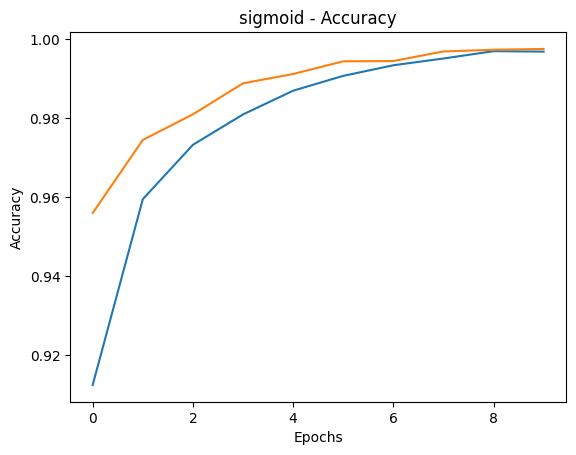

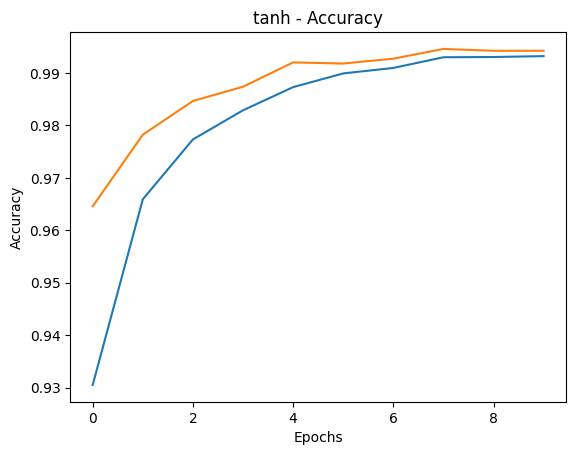

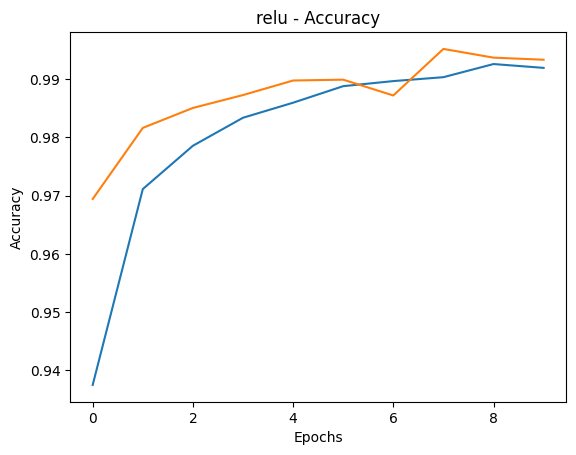

In [8]:
for af in activation:
    history=results[af]
    plt.plot(history.history['accuracy'],label=f'{af}-training accuracy')
    plt.plot(history.history['val_accuracy'],label=f'{af}validation accuracy')
    plt.title(f'{af} - Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()